## 放款数据总结与违约分析

- **第一部分：放款数据总结**：汇总表（指标/数值）、贷款状态分布，按信用等级/用途/收入核验等维度的笔数、放款总金额、平均放款金额、违约率
- **第二部分：违约分析**：按等级、利率分箱、DTI 分箱、循环使用率分箱、近两年逾期次数、破产记录等维度的违约率

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
DATA_DIR=Path('../data')
df=pd.read_csv(DATA_DIR/'myself_loan_clean.csv',low_memory=False)
df.shape


(167981, 52)

In [ ]:
print('Defauli rate is',f'{df['is_default'].mean():.2%}')
df[["loan_status", "is_default", "funded_amnt", "grade"]].head()
df['grade'].value_counts() #看看有哪些分级和个数

Defauli rate is 1.18%


grade
A    50701
B    46403
C    40330
D    22433
E     7077
F      856
G      181
Name: count, dtype: int64

**数据概览（表格总结）**  
- 样本量：约 **16.8 万** 条已放款记录，**52** 个字段特征。  
- 整体违约率：**1.18%**（将 'Late (31-120 days)','In Grace Period','Late (16-30 days)','Charged Off' 视为违约，'Current' 和 'Fully Paid' 视作不违约）。  
- 为后续放款数据总结与违约分析提供统一口径的违约标签与基础字段。

### 第一部分：总结放款数据

汇总表（指标 / 数值）、贷款状态条形图（笔数 / loan_status），以及按维度的拆分：笔数、放款总金额、平均放款金额、违约率（均为英文列名）。

In [16]:
#引入一个汇总表，字段为贷款笔数（Loan count）、贷款总金额（Total funded amount）和平均贷款金额（Average funded amount）
struct=pd.DataFrame({
    'Metric':['Loan count','Total funded amount','Average funded amount'],
    'Value':[df.shape[0],df['funded_amnt'].sum(),df['funded_amnt'].mean().round(2)],})
display(struct)

,Metric,Value
0,Loan count,1.679810e+05
1,Total funded amount,2.741648e+09
2,Average funded amount,1.632118e+04


**Structure 表总结**  
- **Loan count**：约 16.8 万笔；**Total funded amount**：约 27.4 亿美元；**Average funded amount**：约 1.63 万美元/笔。  
- 用于建立放款规模与笔均金额的基准，便于后续按维度对比。

In [33]:
def struct_by_dim(df,dim):
    g=df.groupby(dim).agg(
        Count=('funded_amnt','count'),
        Total_Funded_Amount=('funded_amnt','sum')
    ).reset_index()
    g['Avg_Funded_Amount']=(g['Total_Funded_Amount']/g['Count']).round(2)
    def_rate=df.groupby(dim)['is_default'].mean().reset_index()
    def_rate=def_rate.rename(columns={'is_default':'Default_Rate'})
    g=g.merge(def_rate,on=dim)
    g['Default_Rate']=g['Default_Rate'].round(4)

    return g

by_grade=struct_by_dim(df,'grade')
print('by_grade')
display(by_grade)

by_grade


,grade,Count,Total_Funded_Amount,Avg_Funded_Amount,Default_Rate
0,A,50701,822215725,16216.95,0.0040
1,B,46403,775797250,16718.69,0.0083
2,C,40330,660206300,16370.10,0.0146
3,D,22433,362028625,16138.22,0.0234
4,E,7077,102929200,14544.19,0.0295
5,F,856,15221725,17782.39,0.0619
6,G,181,3249450,17952.76,0.0718


**By grade 表总结**  
- 笔数：A 最多（约 5.1 万），随等级恶化递减，G 仅约 181 笔。  
- 违约率随等级单调上升：A 0.40% → B 0.83% → C 1.46% → D 2.34% → E 2.95% → F 6.19% → G 7.18%。  
- **结论**：等级与违约率强相关，可用于客群分层与定价/准入。

In [46]:
by_purpose=struct_by_dim(df,'purpose').sort_values('Count',ascending=False).head(10)
print("By purpose (Top 10) order by Count")
display(by_purpose)

by_purpose_dr=by_purpose.sort_values("Default_Rate", ascending=False).head(10)
print("By purpose (Top 10) order by Default Rate")
display(by_purpose_dr)

By purpose (Top 10) order by Count


,purpose,Count,Total_Funded_Amount,Avg_Funded_Amount,Default_Rate
2,debt_consolidation,92690,1628185450,17565.92,0.0122
1,credit_card,46798,747100525,15964.37,0.0084
3,home_improvement,9725,148646225,15284.96,0.0145
8,other,8671,96106775,11083.70,0.0176
5,major_purchase,2952,39075850,13237.08,0.0166
6,medical,1743,16762275,9616.91,0.0178
0,car,1362,13941775,10236.25,0.0117
10,small_business,1035,19246825,18595.97,0.0155
11,vacation,1023,6607400,6458.85,0.0108
4,house,978,15773175,16127.99,0.0164


By purpose (Top 10) order by Default Rate


,purpose,Count,Total_Funded_Amount,Avg_Funded_Amount,Default_Rate
6,medical,1743,16762275,9616.91,0.0178
8,other,8671,96106775,11083.70,0.0176
5,major_purchase,2952,39075850,13237.08,0.0166
4,house,978,15773175,16127.99,0.0164
10,small_business,1035,19246825,18595.97,0.0155
3,home_improvement,9725,148646225,15284.96,0.0145
2,debt_consolidation,92690,1628185450,17565.92,0.0122
0,car,1362,13941775,10236.25,0.0117
11,vacation,1023,6607400,6458.85,0.0108
1,credit_card,46798,747100525,15964.37,0.0084


**By purpose 表总结**  
- **debt_consolidation**、**credit_card** 占主导（约 9.3 万、4.7 万笔），合计超八成。  
- 违约率：credit_card 较低（0.84%），debt_consolidation 约 1.22%，medical 和 other 等略高（约 1.7%–1.8%）。  
- **结论**：用途集中，风险差异明显，可针对高违约用途做额度或定价区分。

In [47]:
by_ver = struct_by_dim(df, "verification_status")
print("By verification_status")
display(by_ver)


By verification_status


,verification_status,Count,Total_Funded_Amount,Avg_Funded_Amount,Default_Rate
0,Not Verified,69266,955510975,13794.81,0.0087
1,Source Verified,70794,1222734500,17271.73,0.0125
2,Verified,27921,563402800,20178.46,0.0176


**By verification_status 表总结**  
- 含义：Verified是指平台已核实借款人提供的收入（如通过税单、工资流水等），可信度最高，风控上通常视为“收入已验证”；Source Verified 是指平台核实了收入来源（如雇主、银行等），但不一定逐笔核对具体金额，可信度介于 Verified 和 Not Verified 之间；Not Verified 是指借款人未提供或平台未对收入做核实。

- 笔数：Not Verified 约 6.9 万、Source Verified 约 7.1 万、Verified 约 2.8 万，分布较均衡。 

- 违约率：Not Verified 最低（0.87%），Source Verified 1.25%，Verified 最高（1.76%）；可能与高额/高风险客户更常被要求核验有关。（可能因为高风险或大额借贷都需要被核实，而这些贷款往往有较大概率违约）

- **结论**：核验状态与违约率非单调，需结合金额与等级一起看。

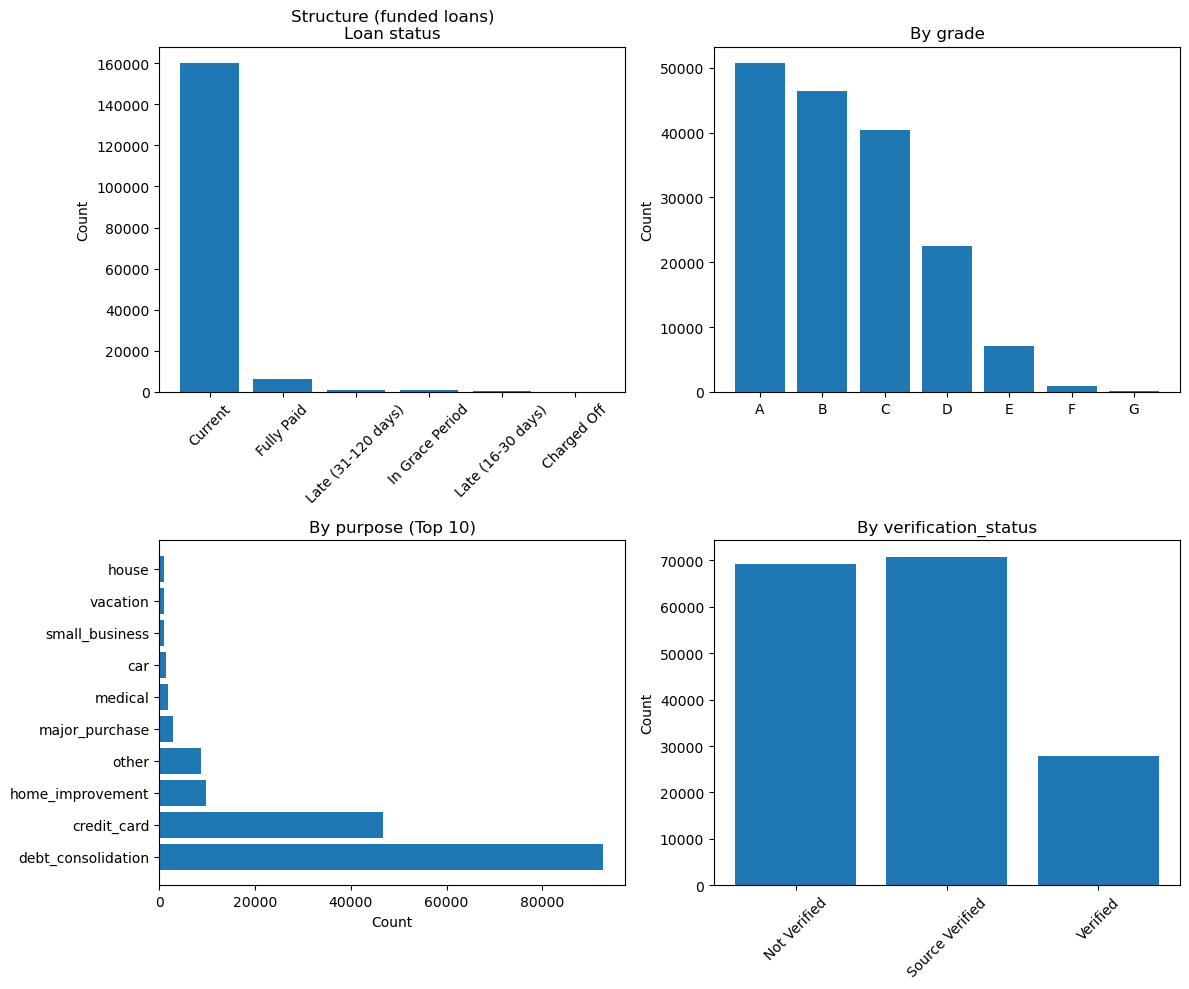

In [48]:
# Structure (funded loans) / By grade / By purpose (Top 10) / By verification_status — 整合为一张图（4 个直方图）
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 左上：Loan status (Structure - funded loans)
v = df["loan_status"].value_counts()
axes[0, 0].bar(range(len(v)), v.values, tick_label=v.index)
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_title("Structure (funded loans)\nLoan status")

# 右上：By grade
axes[0, 1].bar(by_grade["grade"], by_grade["Count"]) #by_grade是按grade分组后的数据，是dataframe，所以by_grade["grade"]是grade的值，by_grade["Count"]是grade的计数
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("By grade")

# 左下：By purpose (Top 10)
axes[1, 0].barh(range(len(by_purpose)), by_purpose["Count"], tick_label=by_purpose["purpose"])
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_title("By purpose (Top 10)")

# 右下：By verification_status
axes[1, 1].bar(by_ver["verification_status"], by_ver["Count"])
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_title("By verification_status")

plt.tight_layout()
plt.show()

### 第二部分：违约分析

违约率按以下维度展示：信用等级、利率分箱、DTI 分箱、循环使用率分箱、近两年逾期次数、破产记录。图表与表格标签为英文。

In [84]:
gr_grade = df.groupby("grade", as_index=False).agg(  #as_index=False表示不将grade作为行索引
    cnt=("is_default", "count"),
    defaults=("is_default", "sum"),
    )
gr_grade["default_rate"] = gr_grade["defaults"] / gr_grade["cnt"]
gr_grade = gr_grade.sort_values("grade")
display(gr_grade)




,grade,cnt,defaults,default_rate
0,A,50701,203,0.004004
1,B,46403,384,0.008275
2,C,40330,589,0.014605
3,D,22433,524,0.023358
4,E,7077,209,0.029532
5,F,856,53,0.061916
6,G,181,13,0.071823


In [88]:
df['int_rate'].describe()
df['int_rate_bin']=pd.cut(df['int_rate'],
    bins=[0,10,15,20,100],
    labels=['0-10%','10-15%','15-20%','20%+'])
df['int_rate_bin'].value_counts()

gr_int_rate=df.groupby('int_rate_bin',observed=True).agg(
    cnt=('is_default','count'),
    defaults=('is_default','sum')
).reset_index()
gr_int_rate['default_rate']=gr_int_rate['defaults']/gr_int_rate['cnt'].round(4)

display(gr_int_rate)

,int_rate_bin,cnt,defaults,default_rate
0,0-10%,50719,204,0.004022
1,10-15%,63412,590,0.009304
2,15-20%,38775,711,0.018337
3,20%+,15075,470,0.031177


In [87]:
df['dti'].describe()
df['dti'].dtype
df['dti_bin']=pd.cut(df['dti'],bins=[0,10,20,30,100],labels=['0-10%','10-20%','20-30%','30%+'])

gr_dti=df.groupby('dti_bin',observed=True).agg(
    cnt=('is_default','count'),
    defaults=('is_default','sum')
).reset_index()
gr_dti['default_rate']=gr_dti['defaults']/gr_dti['cnt'].round(4)

display(gr_dti)




,dti_bin,cnt,defaults,default_rate
0,0-10%,30389,380,0.012505
1,10-20%,66694,710,0.010646
2,20-30%,48570,552,0.011365
3,30%+,21995,323,0.014685


In [99]:
df['revol_util'].describe()
df['revol_util_bin']=pd.cut(df['revol_util'],
    bins=[0,30,50,80,df['revol_util'].max()],
    labels=['0-30%','30-50%','50-80%','>80%'])
df['revol_util_bin'].value_counts()

gr_revol_util=df.groupby('revol_util_bin',observed=True).agg(
    cnt=('is_default','count'),
    defaults=('is_default','sum')
).reset_index()
gr_revol_util['default_rate']=gr_revol_util['defaults']/gr_revol_util['cnt'].round(4)
display(gr_revol_util)


,revol_util_bin,cnt,defaults,default_rate
0,0-30%,52018,573,0.011015
1,30-50%,47188,505,0.010702
2,50-80%,51402,635,0.012354
3,>80%,16221,231,0.014241


In [ ]:
df['delinq_2yrs'].value_counts() #delinq_2yrs为过去两年逾期次数

gr_delinq_2yrs=df.groupby('delinq_2yrs',observed=True).agg(
    cnt=('is_default','count'),
    defaults=('is_default','sum')
).reset_index()
gr_delinq_2yrs['default_rate']=gr_delinq_2yrs['defaults']/gr_delinq_2yrs['cnt'].round(4)
display(gr_delinq_2yrs)


,delinq_2yrs,cnt,defaults,default_rate
0,0,143361,1583,0.011042
1,1,17368,275,0.015834
2,2,4335,69,0.015917
3,3,1486,31,0.020861
4,4,662,13,0.019637
5,5,307,3,0.009772
6,6,177,1,0.005650
7,7,94,0,0.000000
8,8,52,0,0.000000
9,9,41,0,0.000000


In [104]:
df['pub_rec_bankruptcies'].value_counts()
gr_pub_rec_bankruptcies=df.groupby('pub_rec_bankruptcies',observed=True).agg(
    cnt=('is_default','count'),
    defaults=('is_default','sum')
).reset_index()
gr_pub_rec_bankruptcies['default_rate']=gr_pub_rec_bankruptcies['defaults']/gr_pub_rec_bankruptcies['cnt'].round(4)
display(gr_pub_rec_bankruptcies)



,pub_rec_bankruptcies,cnt,defaults,default_rate
0,0,148656,1727,0.011617
1,1,19113,246,0.012871
2,2,184,2,0.010870
3,3,21,0,0.000000
4,4,5,0,0.000000
5,5,1,0,0.000000
6,6,1,0,0.000000


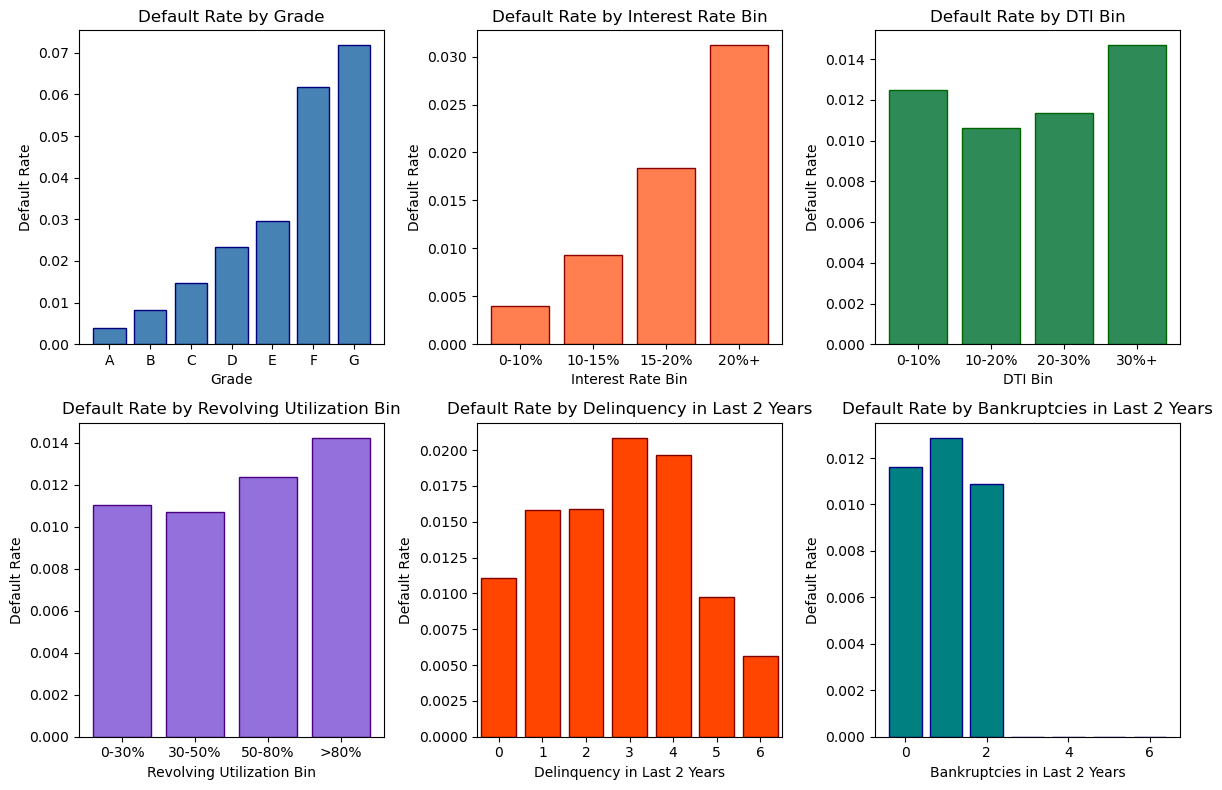

In [110]:
#将以上表格整合到一张2*3的图表中
fig, axes=plt.subplots(2,3,figsize=(12,8))
axes=axes.flatten()

#左上图：违约率与信用等级（grade）
axes[0].bar(gr_grade['grade'],gr_grade['default_rate'],color='steelblue',edgecolor='navy')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Default Rate')
axes[0].set_title('Default Rate by Grade')

#中上图：违约率与利率分箱（int_rate_bin）
axes[1].bar(gr_int_rate['int_rate_bin'],gr_int_rate['default_rate'],color='coral',edgecolor='darkred')
axes[1].set_xlabel('Interest Rate Bin')
axes[1].set_ylabel('Default Rate')
axes[1].set_title('Default Rate by Interest Rate Bin')

#右上图：违约率与DTI分箱（dti_bin）
axes[2].bar(gr_dti['dti_bin'],gr_dti['default_rate'],color='seagreen',edgecolor='darkgreen')
axes[2].set_xlabel('DTI Bin')
axes[2].set_ylabel('Default Rate')
axes[2].set_title('Default Rate by DTI Bin')

#左下图：违约率与循环使用率分箱（revol_util_bin）
axes[3].bar(gr_revol_util['revol_util_bin'],gr_revol_util['default_rate'],color="mediumpurple", edgecolor="indigo")   
axes[3].set_xlabel('Revolving Utilization Bin')
axes[3].set_ylabel('Default Rate')
axes[3].set_title('Default Rate by Revolving Utilization Bin')

#中下图：违约率与过去两年逾期次数（delinq_2yrs）    
axes[4].bar(gr_delinq_2yrs['delinq_2yrs'],gr_delinq_2yrs['default_rate'],color='orangered',edgecolor='maroon')
axes[4].set_xlim(-0.5, 6.5)
axes[4].set_xlabel('Delinquency in Last 2 Years')
axes[4].set_ylabel('Default Rate')
axes[4].set_title('Default Rate by Delinquency in Last 2 Years')

#右下图：违约率与破产记录（pub_rec_bankruptcies）       
axes[5].bar(gr_pub_rec_bankruptcies['pub_rec_bankruptcies'],gr_pub_rec_bankruptcies['default_rate'],color='teal',edgecolor='darkblue')
axes[5].set_xlabel('Bankruptcies in Last 2 Years')
axes[5].set_ylabel('Default Rate')
axes[5].set_title('Default Rate by Bankruptcies in Last 2 Years')

plt.tight_layout()
plt.show()




**违约率表与整合图总结（风险部分）**  
- **Grade**：等级越差违约率越高（A 约 0.4% → G 约 7.2%），与结构表一致。  
- **Int_rate 分箱**：利率越高违约率越高（0–10% 约 0.4%，20%+ 约 3.1%），存在风险与定价联动。  
- **DTI 分箱**：高 DTI（如 30+）违约率更高，建议对高负债比客群收紧或重定价。  
- **Revol_util 分箱**：循环使用率越高违约率越高，>80% 需重点关注。  
- **Delinq_2yrs**：样本量较大时（delinq_2yrs=0,1,2,3），历史违约次数与违约率呈正相关，delinq_2yrs>=4的样本量较小，参考价值不大
- **Pub_rec**：无明显结论
- **结论**：多维度交叉验证了风险与定价、客群特征的一致性，可支撑准入、额度与定价策略。